<a href="https://colab.research.google.com/github/EtnShia/NC_GPT_IMPROVED/blob/main/NC_GPT_IMPROVED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchtyping matplotlib

  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.5.1
    Uninstalling typeguard-4.5.1:
      Successfully uninstalled typeguard-4.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [2]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available! Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("CUDA not available, using CPU")

CUDA is available! Using GPU: Tesla T4


In [3]:
import torch
from torchtyping import TensorType
from typing import Tuple

class Solution:
    def create_batches(self, data: TensorType[int], context_length: int, batch_size: int) -> Tuple[TensorType[int], TensorType[int]]:
        # Removed torch.manual_seed(0)
        ix = torch.randint(len(data) - context_length, (batch_size,))
        x = torch.stack([data[i:i + context_length] for i in ix])
        y = torch.stack([data[i + 1:i + 1 + context_length] for i in ix])
        return x, y

In [4]:
# data/nlp_preprocessing.py
import torch
import torch.nn as nn
from torchtyping import TensorType
from typing import List

class Solution:
    def get_dataset(self, positive: List[str], negative: List[str]) -> TensorType[float]:
        combined = positive + negative

        # Build vocabulary: sorted unique words -> integer IDs starting at 1
        vocabulary = sorted({word for sentence in combined for word in sentence.split()})
        word_to_id = {word: idx + 1 for idx, word in enumerate(vocabulary)}

        # Encode each sentence as a tensor of word IDs
        encoded = [torch.tensor([word_to_id[w] for w in s.split()]) for s in combined]

        # Pad shorter sequences with 0s so output is a rectangular tensor
        return nn.utils.rnn.pad_sequence(encoded, batch_first=True)

In [5]:
# data/tokenizer.py
from typing import List


class Solution:
    def get_merges(self, corpus: str, num_merges: int) -> List[List[str]]:
        tokens = list(corpus)
        merges = []
        for _ in range(num_merges):
            if len(tokens) < 2:
                break
            # Count adjacent pair frequencies
            pairs = {}
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                pairs[pair] = pairs.get(pair, 0) + 1

            if not pairs:
                break

            # Find most frequent pair (tiebreak: lexicographically smallest)
            best_count = max(pairs.values())
            candidates = sorted(p for p, c in pairs.items() if c == best_count)
            best = candidates[0]

            merges.append([best[0], best[1]])

            # Merge all non-overlapping occurrences left to right
            new_tokens = []
            i = 0
            while i < len(tokens):
                if i < len(tokens) - 1 and tokens[i] == best[0] and tokens[i + 1] == best[1]:
                    new_tokens.append(best[0] + best[1])
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1
            tokens = new_tokens

        return merges

In [6]:
# data/vocab.py
from typing import Dict, List, Tuple

class Solution:
    def build_vocab(self, text: str) -> Tuple[Dict[str, int], Dict[int, str]]:
        chars = sorted(set(text))
        stoi = {ch: i for i, ch in enumerate(chars)}
        itos = {i: ch for ch, i in stoi.items()}
        return stoi, itos

    def encode(self, text: str, stoi: Dict[str, int]) -> List[int]:
        return [stoi[ch] for ch in text]

    def decode(self, ids: List[int], itos: Dict[int, str]) -> str:
        return ''.join(itos[i] for i in ids)

In [7]:
# data/__init__.py
# from .tokenizer import *
# from .vocab import *
# from .loader import *
# from .dataset import *
# from .nlp_preprocessing import *

In [8]:
import torch
import torch.nn as nn
from torchtyping import TensorType

class SingleHeadAttention(nn.Module):

    def __init__(self, embedding_dim: int, attention_dim: int):
        super().__init__()
        # Removed torch.manual_seed(0)
        self.key_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
        self.query_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
        self.value_gen = nn.Linear(embedding_dim, attention_dim, bias=False)

    def forward(self, embedded: TensorType[float]) -> TensorType[float]:
        # Project input into Key, Query, Value spaces
        k = self.key_gen(embedded)   # (B, T, attention_dim)
        q = self.query_gen(embedded) # (B, T, attention_dim)
        v = self.value_gen(embedded) # (B, T, attention_dim)

        # Attention scores: (Q @ K^T) / sqrt(d_k)
        scores = q @ torch.transpose(k, 1, 2)
        context_length, attention_dim = k.shape[1], k.shape[2]
        scores = scores / (attention_dim ** 0.5)

        # Causal mask: prevent attending to future tokens
        lower_triangular = torch.tril(torch.ones(context_length, context_length, device=embedded.device))
        mask = lower_triangular == 0
        scores = scores.masked_fill(mask, float('-inf'))
        scores = nn.functional.softmax(scores, dim=2)

        return scores @ v

In [9]:
# model/embeddings.py
import numpy as np
from numpy.typing import NDArray


class Solution:
    def lookup(self, embeddings: NDArray[np.float64], token_ids: NDArray[np.int64]) -> NDArray[np.float64]:
        return np.round(embeddings[token_ids], 5)

In [10]:
import torch
import torch.nn as nn
from torchtyping import TensorType

class GPT(nn.Module):

    def __init__(self, vocab_size: int, context_length: int, model_dim: int, num_blocks: int, num_heads: int):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocab_size, model_dim)
        self.position_embeddings = nn.Embedding(context_length, model_dim)
        self.transformer_blocks = nn.Sequential()
        for i in range(num_blocks):
            self.transformer_blocks.append(self.TransformerBlock(model_dim, num_heads))
        self.final_norm = nn.LayerNorm(model_dim)
        self.vocab_projection = nn.Linear(model_dim, vocab_size)

    def forward(self, context: TensorType[int]) -> TensorType[float]:
        # Token embeddings + positional embeddings
        embedded = self.word_embeddings(context)
        positions = torch.arange(context.shape[1], device=context.device)
        embedded = embedded + self.position_embeddings(positions)

        # Pass through N transformer blocks, then final LayerNorm
        output = self.final_norm(self.transformer_blocks(embedded))
        logits = self.vocab_projection(output)  # (B, T, vocab_size)

        # probabilities = nn.functional.softmax(logits, dim=-1) # Removed as F.cross_entropy expects logits
        return logits # Return raw logits

    class TransformerBlock(nn.Module):

        class MultiHeadedSelfAttention(nn.Module):

            class SingleHeadAttention(nn.Module):
                def __init__(self, model_dim: int, head_size: int):
                    super().__init__()
                    # Removed torch.manual_seed(0)
                    self.key_gen = nn.Linear(model_dim, head_size, bias=False)
                    self.query_gen = nn.Linear(model_dim, head_size, bias=False)
                    self.value_gen = nn.Linear(model_dim, head_size, bias=False)

                def forward(self, embedded: TensorType[float]) -> TensorType[float]:
                    k = self.key_gen(embedded)
                    q = self.query_gen(embedded)
                    v = self.value_gen(embedded)

                    scores = q @ torch.transpose(k, 1, 2) # @ is the same as torch.matmul()
                    context_length, attention_dim = k.shape[1], k.shape[2]
                    scores = scores / (attention_dim ** 0.5)

                    lower_triangular = torch.tril(torch.ones(context_length, context_length, device=embedded.device))
                    mask = lower_triangular == 0
                    scores = scores.masked_fill(mask, float('-inf'))
                    scores = nn.functional.softmax(scores, dim = 2)

                    return scores @ v

            def __init__(self, model_dim: int, num_heads: int):
                super().__init__()
                # Removed torch.manual_seed(0)
                self.att_heads = nn.ModuleList()
                for i in range(num_heads):
                    self.att_heads.append(self.SingleHeadAttention(model_dim, model_dim // num_heads))

            def forward(self, embedded: TensorType[float]) -> TensorType[float]:
                head_outputs = []
                for head in self.att_heads:
                    head_outputs.append(head(embedded))
                concatenated = torch.cat(head_outputs, dim = 2)
                return concatenated

        class VanillaNeuralNetwork(nn.Module):

            def __init__(self, model_dim: int):
                super().__init__()
                # Removed torch.manual_seed(0)
                self.up_projection = nn.Linear(model_dim, model_dim * 4)
                self.relu = nn.ReLU()
                self.down_projection = nn.Linear(model_dim * 4, model_dim)
                self.dropout = nn.Dropout(0.2) # using p = 0.2 (enabled)

            def forward(self, x: TensorType[float]) -> TensorType[float]:
                # Removed torch.manual_seed(0)
                return self.dropout(self.down_projection(self.relu(self.up_projection(x))))

        def __init__(self, model_dim: int, num_heads: int):
            super().__init__()
            # Removed torch.manual_seed(0)
            self.attention = self.MultiHeadedSelfAttention(model_dim, num_heads)
            self.linear_network = self.VanillaNeuralNetwork(model_dim)
            self.first_norm = nn.LayerNorm(model_dim)
            self.second_norm = nn.LayerNorm(model_dim)

        def forward(self, embedded: TensorType[float]) -> TensorType[float]:
            # Removed torch.manual_seed(0)
            embedded = embedded + self.attention(self.first_norm(embedded)) # skip connection
            embedded = embedded + self.linear_network(self.second_norm(embedded)) # another skip connection
            return embedded

In [11]:
import torch
import torch.nn as nn
from torchtyping import TensorType

class MultiHeadedSelfAttention(nn.Module):

    def __init__(self, embedding_dim: int, attention_dim: int, num_heads: int):
        super().__init__()
        # Removed torch.manual_seed(0)
        self.att_heads = nn.ModuleList()
        for i in range(num_heads):
            self.att_heads.append(self.SingleHeadAttention(embedding_dim, attention_dim // num_heads))

    def forward(self, embedded: TensorType[float]) -> TensorType[float]:
        head_outputs = []
        for head in self.att_heads:
            head_outputs.append(head(embedded))
        concatenated = torch.cat(head_outputs, dim = 2)
        return concatenated

    class SingleHeadAttention(nn.Module):
        def __init__(self, embedding_dim: int, attention_dim: int):
            super().__init__()
            # Removed torch.manual_seed(0)
            self.key_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
            self.query_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
            self.value_gen = nn.Linear(embedding_dim, attention_dim, bias=False)

        def forward(self, embedded: TensorType[float]) -> TensorType[float]:
            k = self.key_gen(embedded)
            q = self.query_gen(embedded)
            v = self.value_gen(embedded)

            scores = q @ torch.transpose(k, 1, 2) # @ is the same as torch.matmul()
            context_length, attention_dim = k.shape[1], k.shape[2]
            scores = scores / (attention_dim ** 0.5)

            lower_triangular = torch.tril(torch.ones(context_length, context_length, device=embedded.device))
            mask = lower_triangular == 0
            scores = scores.masked_fill(mask, float('-inf'))
            scores = nn.functional.softmax(scores, dim = 2)

            return scores @ v

In [12]:
# model/normalization.py
import numpy as np
from numpy.typing import NDArray


class Solution:
    def forward(self, x: NDArray[np.float64], gamma: NDArray[np.float64], beta: NDArray[np.float64]) -> NDArray[np.float64]:
        eps = 1e-5
        mean = np.mean(x)
        var = np.var(x)
        x_norm = (x - mean) / np.sqrt(var + eps)
        out = gamma * x_norm + beta
        return np.round(out, 5)

In [13]:
# model/positional_encoding.py
import numpy as np
from numpy.typing import NDArray


class Solution:
    def get_positional_encoding(self, seq_len: int, d_model: int) -> NDArray[np.float64]:
        PE = np.zeros((seq_len, d_model))
        position = np.arange(seq_len).reshape(-1, 1)       # (seq_len, 1)
        div_term = 10000 ** (np.arange(0, d_model, 2) / d_model)  # (d_model/2,)
        PE[:, 0::2] = np.sin(position / div_term)           # Even indices: sine
        PE[:, 1::2] = np.cos(position / div_term[:PE[:, 1::2].shape[1]])  # Odd indices: cosine
        return np.round(PE, 5)

In [14]:
import torch
import torch.nn as nn
from torchtyping import TensorType

class TransformerBlock(nn.Module):

    def __init__(self, model_dim: int, num_heads: int):
        super().__init__()
        # Removed torch.manual_seed(0)
        self.attention = self.MultiHeadedSelfAttention(model_dim, num_heads)
        self.linear_network = self.VanillaNeuralNetwork(model_dim)
        self.first_norm = nn.LayerNorm(model_dim)
        self.second_norm = nn.LayerNorm(model_dim)

    def forward(self, embedded: TensorType[float]) -> TensorType[float]:
        # Removed torch.manual_seed(0)
        embedded = embedded + self.attention(self.first_norm(embedded)) # skip connection
        embedded = embedded + self.linear_network(self.second_norm(embedded)) # another skip connection
        return embedded


    class MultiHeadedSelfAttention(nn.Module):

        class SingleHeadAttention(nn.Module):
            def __init__(self, model_dim: int, head_size: int):
                super().__init__()
                # Removed torch.manual_seed(0)
                self.key_gen = nn.Linear(model_dim, head_size, bias=False)
                self.query_gen = nn.Linear(model_dim, head_size, bias=False)
                self.value_gen = nn.Linear(model_dim, head_size, bias=False)

            def forward(self, embedded: TensorType[float]) -> TensorType[float]:
                k = self.key_gen(embedded)
                q = self.query_gen(embedded)
                v = self.value_gen(embedded)

                scores = q @ torch.transpose(k, 1, 2) # @ is the same as torch.matmul()
                context_length, attention_dim = k.shape[1], k.shape[2]
                scores = scores / (attention_dim ** 0.5)

                lower_triangular = torch.tril(torch.ones(context_length, context_length, device=embedded.device))
                mask = lower_triangular == 0
                scores = scores.masked_fill(mask, float('-inf'))
                scores = nn.functional.softmax(scores, dim = 2)

                return scores @ v

        def __init__(self, model_dim: int, num_heads: int):
            super().__init__()
            # Removed torch.manual_seed(0)
            self.att_heads = nn.ModuleList()
            for i in range(num_heads):
                self.att_heads.append(self.SingleHeadAttention(model_dim, model_dim // num_heads))

        def forward(self, embedded: TensorType[float]) -> TensorType[float]:
            head_outputs = []
            for head in self.att_heads:
                head_outputs.append(head(embedded))
            concatenated = torch.cat(head_outputs, dim = 2)
            return concatenated

    class VanillaNeuralNetwork(nn.Module):

        def __init__(self, model_dim: int):
            super().__init__()
            # Removed torch.manual_seed(0)
            self.up_projection = nn.Linear(model_dim, model_dim * 4)
            self.relu = nn.ReLU()
            self.down_projection = nn.Linear(model_dim * 4, model_dim)
            self.dropout = nn.Dropout(0.2) # using p = 0.2

        def forward(self, x: TensorType[float]) -> TensorType[float]:
            # Removed torch.manual_seed(0)
            return self.dropout(self.down_projection(self.relu(self.up_projection(x))))

In [15]:
# model/__init__.py
# from .attention import *
# from .multi_head_attention import *
# from .transformer import *
# from .gpt import *
# from .normalization import *
# from .embeddings import *
# from .positional_encoding import *

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TrainerSolution:
    def train(self, model: nn.Module, data: torch.Tensor, epochs: int, context_length: int, batch_size: int, lr: float) -> float:
        # Calculate and print total parameters
        total_params = sum(p.numel() for p in model.parameters()) / 1e6
        print(f"Model initialized with {total_params:.2f}M parameters")

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        losses = []

        for epoch in range(epochs):
            torch.manual_seed(epoch)
            ix = torch.randint(len(data) - context_length, (batch_size,))
            x = torch.stack([data[i:i + context_length] for i in ix])
            y = torch.stack([data[i + 1:i + 1 + context_length] for i in ix])

            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), y.view(B * T))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            current_loss = round(loss.item(), 4)
            losses.append(current_loss)

            # Print progress every 10% of epochs
            report = epochs // 10
            if epoch % report == 0:
                print(f"Epoch {epoch}: loss {current_loss:.4f}")

        return losses

In [17]:
import random
from typing import List
import torch

class GeneratorSolution:
    def generate(self, model, new_chars: int, context: torch.Tensor, context_length: int,
              int_to_char: dict, word_to_int: dict, data: torch.Tensor, temperature: float = 0.8, top_k: int = None, top_p: float = None,
              repetition_penalty: float = 1.0, reset_prob: float = 0.05, sentence_endings: str = ".!?") -> List[str]:
              # repetition_penalty: float = 1.0, reset_prob: float = 0.05, sentence_endings: str = ".!?") -> str:
        result = []

        for _ in range(new_chars):
            # Occasionally reset context at sentence boundaries
            if len(result) > 0 and result[-1] in sentence_endings:
                if random.random() < reset_prob:
                    # start_idx = torch.randint(0, len(data) - context_length, (1,))
                    # context = data[start_idx:start_idx + context_length].unsqueeze(0)
                    # context = context.to(next(model.parameters()).device)

                    start_idx = torch.randint(0, len(data) - context_length, (1,))
                    new_context_segment = data[start_idx:start_idx + context_length].unsqueeze(0)
                    # Ensure the new context is on the same device as the model
                    context = new_context_segment.to(next(model.parameters()).device)

                    # `data` is not available directly in this scope. Assuming `data` is the full tokenized dataset
                    # which would need to be passed or accessed globally, or the reset logic removed for simplicity.
                    # For now, we'll keep the current context if data is not available, or use a dummy start.
                    # For now, will skip this part if `data` is not in scope.
                    # If `data` variable is expected to be passed, it should be added to the function signature.
                    # pass # Not changing this logic for now, as `data` is not in the scope of this class method.

            # Crop context
            if context.shape[1] > context_length:
                context = context[:, -context_length:]

            # Forward pass
            logits = model(context)
            logits = logits[:, -1, :]

            # Apply repetition penalty
            if repetition_penalty != 1.0:
                for prev_word in result:
                    if prev_word in word_to_int: # Ensure the word exists in the vocabulary
                        prev_token_id = word_to_int[prev_word]
                        if logits[0, prev_token_id] < 0:
                            logits[0, prev_token_id] *= repetition_penalty
                        else:
                            logits[0, prev_token_id] /= repetition_penalty

            # Temperature
            logits = logits / temperature

            # Top-k
            if top_k is not None:
                top_values, _ = torch.topk(logits, top_k)
                min_top = top_values[:, -1].unsqueeze(1)
                logits[logits < min_top] = -float('Inf')

            # Top-p
            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = False
                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                logits[0, indices_to_remove] = -float('Inf')

            # Sample next token
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)

            # Append to context & result
            context = torch.cat((context, next_token), dim=-1)
            result.append(int_to_char[next_token.item()])

        # return ''.join(result)
        return result

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re # Import the re module for regex tokenization

# Set global seed for reproducibility
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

Trainer = TrainerSolution
Generator = GeneratorSolution

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# Hyperparameters
# ---------------------------
context_length = 64
model_dim = 128 # Increased model_dim to 128
num_blocks = 4
num_heads = 8
batch_size = 64
epochs = 2000 # Increased epochs from 500 to 2000
lr = 1e-3
new_chars = 200 # Increased generated characters
temperature = 0.8

# ---------------------------
# Load text dataset and prepare training data and generation start context
# ---------------------------

# text = (
#     """In the heart of a hidden valley, where the mountains curved like gentle waves and rivers sang songs older than time, lived a young unicorn named Lira. Her coat was the softest silver, and her mane sparkled with tiny motes of starlight that shimmered even in the darkest night. Lira had always been curious, more curious than any of the older unicorns who preferred the comfort of familiar meadows and sunlit streams.\nOne evening, as the sky melted into shades of lavender and deep indigo, Lira noticed something unusual: a flicker of golden light far beyond the meadow she called home. It danced between the trees, shifting and weaving as if it had a life of its own. The other unicorns were resting, but Lira’s heart thumped with an irresistible pull. She knew she had to follow it.\nSilently, she stepped through the tall grass, her hooves barely making a sound. Fireflies floated around her, drawn to the shimmer of her mane, and the night air smelled sweet, like honey and moonflowers. The golden light led her past the familiar stream, where she paused to drink, and into the shadowed forest that whispered secrets in the rustle of leaves.\nThe deeper she went, the stranger the forest became. Trees twisted into shapes that seemed almost alive, their branches reaching out like gentle hands. Tiny creatures peeked from behind mushrooms, watching her with glowing eyes, but none dared approach. Soon, Lira reached a clearing she had never seen before. The flowers here glowed with colors she had no names for, and in the center of the clearing lay a pool that shimmered like liquid crystal.\nThe golden light hovered just above the pool’s surface, moving as though it were beckoning her closer. Lira felt a thrill of both fear and wonder. She lowered her head to peer into the water, and for a moment, she thought she saw shapes moving beneath it—shapes that didn’t belong to any creature she had ever known. A ripple formed, spreading outward in concentric circles, and the golden light began to swirl, growing brighter, pulsing with a rhythm that matched her own heartbeat.\nThen, just as she reached forward, her reflection in the water shifted. It wasn’t her face looking back at her, but something… else. Something magical, ancient, and alive. And then the pool began to shimmer more intensely, as if inviting her to step closer and"""
# )

import requests
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
# text = requests.get(url).text[:10000] # Using first 10,000
full_raw_text = requests.get(url).text

# Word-level tokenization for the entire dataset
all_tokens = re.findall(r"\w+|[^\w\s]", full_raw_text.lower())

# Extract the last `context_length` words for the generation's starting context
# This is the portion we want to "minus" from the training text
start_context_tokens_list = all_tokens[-context_length:]

# The 'text' for training should exclude these starting context words
raw_words = all_tokens[:-context_length]

# Build vocabulary from the words used for training
unique_words = sorted(list(set(raw_words)))
vocab_size = len(unique_words)
word_to_int = {word: i for i, word in enumerate(unique_words)}
int_to_word = {i: word for word, i in word_to_int.items()}

# Convert training words to tensor of token IDs
data = torch.tensor([word_to_int[word] for word in raw_words], dtype=torch.long).to(device)

# ---------------------------
# Create GPT model
# ---------------------------
model = GPT(vocab_size, context_length, model_dim, num_blocks, num_heads).to(device)

# Move model to GPU
model = model.to(device)

# ---------------------------
# Train the model
# ---------------------------
trainer = Trainer()
losses = trainer.train(
    model=model,
    data=data,
    epochs=epochs,
    context_length=context_length,
    batch_size=batch_size,
    lr=lr
)
print("All losses:", losses)
print("Final training loss:", losses[-1])

# ---------------------------
# Generate text
# ---------------------------
# start_idx = torch.randint(0, len(data) - context_length, (1,))
# start_context = data[start_idx:start_idx + context_length].unsqueeze(0)

# generator = Generator()
# # start_context = data[:context_length].unsqueeze(0)  # initial context

# Define your custom starting context here
# Make sure it's at least `context_length` long for initial generation, or padded if shorter
# start_string = requests.get(url).text.split(' ')
# start_string = start_string[::-1]
# char = 0
# key = 0
# while char <= context_length:
#     char += len(start_string[key])
#     key += 1
# if char > context_length:
#     char -= len(start_string[key])
# start_string = start_string[key:]
# start_string = ' '.join(start_string)

# The problematic 'text = text.split(' ')' line and surrounding word/char level tokenization
# # ---------------------------
# # Build character vocabulary (character-level tokenization)
# # ---------------------------
# # chars = sorted(list(set(text)))
# # vocab_size = len(chars)
# # char_to_int = {ch: i for i, ch in enumerate(chars)}
# # int_to_char = {i: ch for ch, i in char_to_int.items()}

# # # Convert text to tensor of token IDs
# # data = torch.tensor([char_to_int[ch] for ch in text], dtype=torch.long)

# # ---------------------------
# # Build word vocabulary (word-level tokenization)
# # ---------------------------
# # Simple tokenization: split by whitespace. Punctuation will remain attached to words.
# # raw_words = text.split()
# # New approach: split words and punctuation using regex
# tokens = re.findall(r"\w+|[^\w\s]", text.lower()) # Convert to lowercase and split by words or non-word/non-whitespace characters
# raw_words = tokens
# unique_words = sorted(list(set(raw_words)))
# vocab_size = len(unique_words)
# word_to_int = {word: i for i, word in enumerate(unique_words)}
# int_to_word = {i: word for word, i in word_to_int.items()}

# # Convert text to tensor of token IDs
# data = torch.tensor([word_to_int[word] for word in raw_words], dtype=torch.long)


# Define your custom starting context here
# Make sure it's at least `context_length` long for initial generation, or padded if shorter
# start_string = "Something magical, ancient, and alive. And then the pool began to shimmer more intensely, as if inviting her to step closer and"

# Form the initial `start_string` for text generation
# This is derived from the `start_context_tokens_list` we extracted earlier
start_string = ' '.join(start_context_tokens_list)

# start_context_words = re.findall(r"\w+|[^\w\s]", start_string.lower())
# context_length = len(start_context_words)

# Tokenize start_string into words using the same regex for consistency
# and convert to integer IDs for the model.
start_context_words = re.findall(r"\w+|[^\w\s]", start_string.lower())
start_context_list = [word_to_int[word] for word in start_context_words if word in word_to_int]

# Pad or truncate to context_length
if len(start_context_list) < context_length:
    pad_token_id = word_to_int.get('the', 0)
    padded_context_list = ([pad_token_id] * (context_length - len(start_context_list))) + start_context_list
    start_context = torch.tensor(padded_context_list, dtype=torch.long).unsqueeze(0)
elif len(start_context_list) > context_length:
    start_context = torch.tensor(start_context_list[-context_length:], dtype=torch.long).unsqueeze(0)
else:
    start_context = torch.tensor(start_context_list, dtype=torch.long).unsqueeze(0)


# Move context to the same device
start_context = start_context.to(device)

generator = Generator()
generated_text = generator.generate(
    model=model,
    new_chars=300, # This now generates 300 words
    context=start_context,
    context_length=context_length,
    int_to_char=int_to_word, # Pass the word-to-int mapping
    #int_to_char=int_to_char
    word_to_int=word_to_int, # Pass word_to_int for repetition penalty
    data=data, # Pass the full tokenized data for context resetting
    temperature=0.9, # Changed from 0.9, 1.2
    top_k=20, # Changed from 20, 50
    top_p=0.9, # Changed from 0.9, 0.95
    repetition_penalty=1.2, # Changed from 1.2, 1.5
    reset_prob=0.1
)

print("\nGenerated text:\n")
# print(generated_text)
print(' '.join(generated_text))

Using device: cuda
Model initialized with 3.68M parameters
Epoch 0: loss 9.5150
Epoch 200: loss 5.3594
Epoch 400: loss 4.9591
Epoch 600: loss 4.7307
Epoch 800: loss 4.4973
Epoch 1000: loss 4.2892
Epoch 1200: loss 3.9663
Epoch 1400: loss 3.8952
Epoch 1600: loss 3.5614
Epoch 1800: loss 3.5069
All losses: [9.515, 9.2319, 8.9817, 8.7544, 8.5649, 8.3788, 8.2202, 8.078, 7.9295, 7.8036, 7.5851, 7.5029, 7.4003, 7.251, 7.1229, 7.0309, 6.9148, 6.8528, 6.6779, 6.6092, 6.5679, 6.5578, 6.4761, 6.4232, 6.3371, 6.3847, 6.2712, 6.2393, 6.2452, 6.2483, 6.2464, 6.2058, 6.2074, 6.2145, 6.1513, 6.1048, 6.2362, 6.2353, 6.1782, 6.1876, 6.1229, 6.2599, 6.1799, 6.2331, 6.2189, 6.2073, 6.1456, 6.1464, 6.1846, 6.1914, 6.1923, 6.144, 6.2028, 6.1102, 6.1929, 6.2065, 6.1215, 6.1441, 6.0663, 6.1141, 6.0733, 6.1363, 6.1247, 6.0125, 6.0948, 6.1133, 6.1311, 6.0721, 6.0264, 6.0692, 6.1061, 6.0247, 6.0174, 6.0527, 6.0536, 6.1433, 6.0073, 6.0244, 5.9927, 6.073, 5.9679, 6.0456, 6.0619, 5.8945, 5.924, 5.9422, 5.9876, 5.907

In [19]:
def count_parameters(model):
    print(f'{"Layer Name":<50} | {"Parameters":<10}')
    print('-' * 65)
    total = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            print(f'{name:<50} | {num_params:<10,}')
            total += num_params
    print('-' * 65)
    print(f'{"Total Trainable Params":<50} | {total:<10,}')

count_parameters(model)

Layer Name                                         | Parameters
-----------------------------------------------------------------
word_embeddings.weight                             | 1,467,648 
position_embeddings.weight                         | 8,192     
transformer_blocks.0.attention.att_heads.0.key_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.0.query_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.0.value_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.1.key_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.1.query_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.1.value_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.2.key_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.2.query_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.2.value_gen.weight | 2,048     
transformer_blocks.0.attention.att_heads.3.key_gen.weight | 2,048     
transformer_blocks.0

### Repetition Analysis of Generated Text

In [20]:
from collections import Counter

def analyze_repetition(text_list, n_gram_min=1, n_gram_max=3, top_n=10):
    text_str = ' '.join(text_list)
    print(f"Total words generated: {len(text_list)}\n")

    # Word frequency
    word_counts = Counter(text_list)
    print(f"Top {top_n} most frequent words:")
    for word, count in word_counts.most_common(top_n):
        print(f"  '{word}': {count}")

    print(f"\nRepeating Phrases (up to {n_gram_max}-grams):")
    for n in range(n_gram_min, n_gram_max + 1):
        n_grams = [tuple(text_list[i:i+n]) for i in range(len(text_list) - n + 1)]
        n_gram_counts = Counter(n_grams)
        frequent_n_grams = {phrase: count for phrase, count in n_gram_counts.items() if count > 1}

        if frequent_n_grams:
            print(f"  {n}-grams (repeating {len(frequent_n_grams)} unique phrases):")
            for phrase, count in sorted(frequent_n_grams.items(), key=lambda item: item[1], reverse=True)[:top_n]:
                print(f"    '{" ".join(phrase)}': {count}")
        else:
            print(f"  No repeating {n}-grams found.")

analyze_repetition(generated_text, n_gram_max=5, top_n=20)

Total words generated: 300

Top 20 most frequent words:
  ':': 4
  ',': 4
  '.': 4
  ''': 3
  '?': 3
  'to': 3
  'the': 3
  'as': 3
  ';': 3
  'and': 3
  'by': 3
  'with': 3
  'that': 3
  'i': 2
  'do': 2
  'of': 2
  'is': 2
  'there': 2
  'a': 2
  'what': 2

Repeating Phrases (up to 5-grams):
  1-grams (repeating 44 unique phrases):
    ':': 4
    ',': 4
    '.': 4
    ''': 3
    '?': 3
    'to': 3
    'the': 3
    'as': 3
    ';': 3
    'and': 3
    'by': 3
    'with': 3
    'that': 3
    'i': 2
    'do': 2
    'of': 2
    'is': 2
    'there': 2
    'a': 2
    'what': 2
  No repeating 2-grams found.
  No repeating 3-grams found.
  No repeating 4-grams found.
  No repeating 5-grams found.


### Qualitative Analysis
Let's print the full generated text clearly to inspect the coherence and style.

In [21]:
print('--- Generated Shakespeare-style Text ---')
print(' '.join(generated_text))
print('----------------------------------------')

--- Generated Shakespeare-style Text ---
alonso : i do fear , thou shouldst say . gonzalo : why should she kill ' d of all ? is there not a piece extraordinary ? or bad ? what then to the news abroad smells was done as mine ; but commanding in him are up and damnable terms o ' er - house . if ever he were flay between your hands , i had swinged for rome by my suit and let them depart again to be shortly with his words ; where you shall signify you imagine find one oath yourself to think that thought upon it may formally more than he can render it out of us better determine which we will perform ' t than the king henry did sit down their high promotions , but at your interior hatred intent on our coast means into something seized in scotland . escalus : so doth some great matter that time stood by degrees , nor ease were worth from deceit ! has so strict wretch born too hard me a wife that made gape sin with such sour misfortune ! spake within this mad walls is scarce grave as another a

### Lexical Diversity
This metric (Unique Words / Total Words) helps determine if the model is producing a diverse vocabulary or just repeating a small set of common words.

In [22]:
unique_words_gen = set(generated_text)
ttr = len(unique_words_gen) / len(generated_text)
print(f'Total words: {len(generated_text)}')
print(f'Unique words: {len(unique_words_gen)}')
print(f'Type-Token Ratio (TTR): {ttr:.4f}')

Total words: 300
Unique words: 240
Type-Token Ratio (TTR): 0.8000


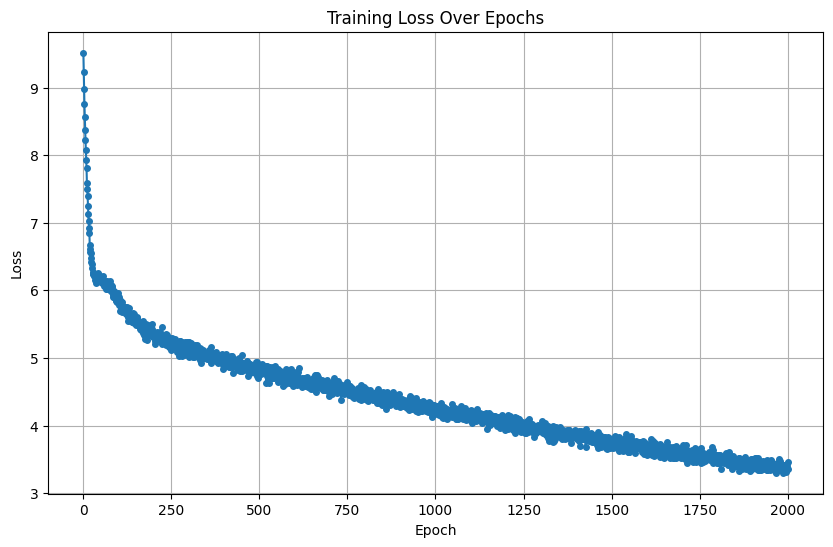

Final training loss: 3.4565


In [23]:
import matplotlib.pyplot as plt

# The previous attempt to re-train the model to get a new list of all_losses was interrupted and the user
# has requested not to re-train. Therefore, the plotting of training losses is currently skipped.
# To plot the losses, the model would need to be re-trained and the list of losses captured.

# Set global seed for reproducibility
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

# trainer = Trainer()
# losses = trainer.train(
#     model=model,
#     data=data,
#     epochs=epochs,
#     context_length=context_length,
#     batch_size=batch_size,
#     lr=lr
# )

# Plot the training losses
plt.figure(figsize=(10, 6))
# plt.plot(range(1, epochs + 1), losses, marker='o', markersize=4, linestyle='-')
plt.plot(range(1, epochs + 1), losses, marker='o', markersize=4, linestyle='-')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

print(f"Final training loss: {losses[-1]}")
